# Lab P2: Hidden Layers and Backpropagation

**Goal:** Discover why one neuron isn't enough, build a hidden layer network, and implement backpropagation — all from scratch.

**What you'll learn:**
- Why linear neurons can't learn curves (and see the failure)
- ReLU activation: the simplest nonlinearity
- Hidden layers: neurons that figure out their own features
- Forward pass: input to output, step by step
- Backward pass (backpropagation): blame flows backwards
- Train a 2-layer network that learns `y = |x|`

**Time:** ~60 minutes

---

## Part 1: Why One Neuron Fails

A single neuron computes `y = wx + b` — that's a straight line. What if the data is curved?

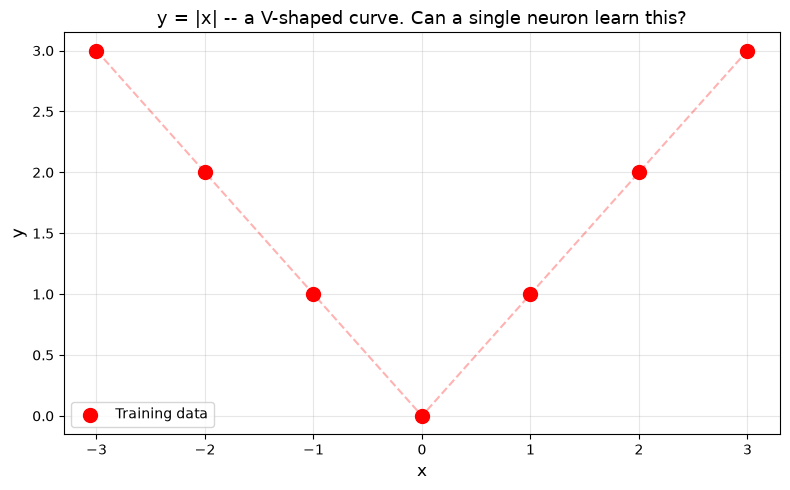

A straight line CAN'T fit this V-shape. Let's prove it.


In [1]:
import matplotlib.pyplot as plt

# Data: y = |x| (V-shaped curve)
X_train = [-3, -2, -1, 0, 1, 2, 3]
Y_train = [ 3,  2,  1, 0, 1, 2, 3]   # absolute value

# Visualize the data
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train, Y_train, color='red', s=100, zorder=5, label='Training data')
ax.plot(X_train, Y_train, 'r--', alpha=0.3)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('y = |x| -- a V-shaped curve. Can a single neuron learn this?', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("A straight line CAN'T fit this V-shape. Let's prove it.")

In [2]:
# Try to train a single neuron on y = |x|
def mse_loss(predictions, targets):
    return sum((p - t) ** 2 for p, t in zip(predictions, targets)) / len(targets)

weight = 0.5
bias = 0.0
lr = 0.01
nudge = 0.001

loss_history = []

for step in range(200):
    # Forward pass
    predictions = [weight * x + bias for x in X_train]
    loss = mse_loss(predictions, Y_train)
    loss_history.append(loss)

    # Gradient for weight
    preds_nudge = [(weight + nudge) * x + bias for x in X_train]
    grad_w = (mse_loss(preds_nudge, Y_train) - loss) / nudge

    # Gradient for bias
    preds_nudge = [weight * x + (bias + nudge) for x in X_train]
    grad_b = (mse_loss(preds_nudge, Y_train) - loss) / nudge

    weight -= lr * grad_w
    bias -= lr * grad_b

print(f"After 200 steps: w={weight:.4f}, b={bias:.4f}, loss={loss_history[-1]:.4f}")
print(f"\nLoss is stuck at {loss_history[-1]:.2f} -- it can't go lower!")

After 200 steps: w=-0.0005, b=1.6836, loss=1.0622

Loss is stuck at 1.06 -- it can't go lower!


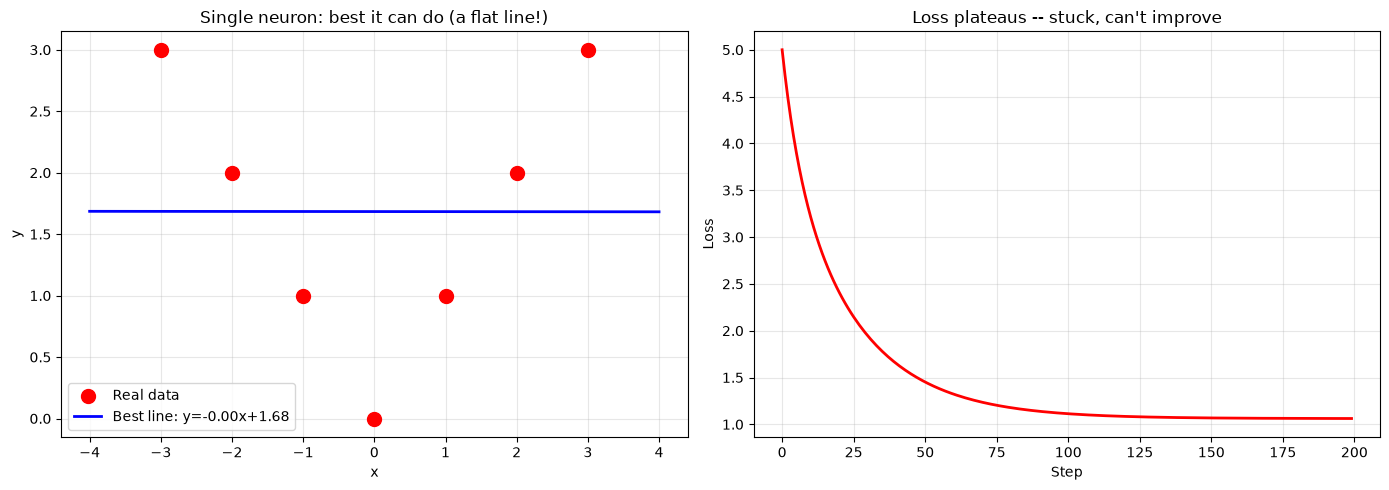

The neuron converged to w~0, b~1.7 (a flat horizontal line).
It's the BEST straight line for this data, but it's still terrible.

We need something that can bend. Enter: ReLU.


In [3]:
# Show the neuron's best attempt vs the real data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# The fit
x_line = [i/10 for i in range(-40, 41)]
y_line = [weight * x + bias for x in x_line]
axes[0].scatter(X_train, Y_train, color='red', s=100, zorder=5, label='Real data')
axes[0].plot(x_line, y_line, 'b-', linewidth=2, label=f'Best line: y={weight:.2f}x+{bias:.2f}')
axes[0].set_title('Single neuron: best it can do (a flat line!)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

# Loss plateau
axes[1].plot(loss_history, 'r-', linewidth=2)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss plateaus -- stuck, can\'t improve', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The neuron converged to w~0, b~1.7 (a flat horizontal line).")
print("It's the BEST straight line for this data, but it's still terrible.")
print("\nWe need something that can bend. Enter: ReLU.")

---
## Part 2: ReLU — The Activation Function

**ReLU** = Rectified Linear Unit. Dead simple:

$$ReLU(z) = max(0, z)$$

- If z > 0: output z (pass through)
- If z <= 0: output 0 (block it)

It's like a gate that only opens for positive values.

ReLU in action:
  ReLU(-3) = 0
  ReLU(-1) = 0
  ReLU(+0) = 0
  ReLU(+1) = 1
  ReLU(+3) = 3
  ReLU(+5) = 5


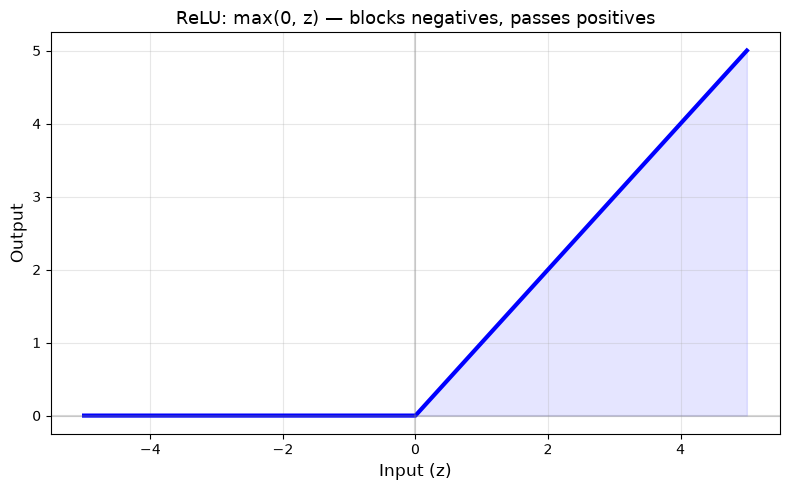

In [4]:
def relu(z):
    return max(0, z)

# Test it
test_values = [-3, -1, 0, 1, 3, 5]
print("ReLU in action:")
for z in test_values:
    print(f"  ReLU({z:+d}) = {relu(z)}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
z_vals = [z/10 for z in range(-50, 51)]
r_vals = [relu(z) for z in z_vals]
ax.plot(z_vals, r_vals, 'b-', linewidth=3)
ax.axhline(y=0, color='gray', alpha=0.3)
ax.axvline(x=0, color='gray', alpha=0.3)
ax.set_xlabel('Input (z)', fontsize=12)
ax.set_ylabel('Output', fontsize=12)
ax.set_title('ReLU: max(0, z) — blocks negatives, passes positives', fontsize=13)
ax.fill_between(z_vals, r_vals, alpha=0.1, color='blue')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Why ReLU solves the problem

Two ReLU neurons can create a V-shape:
- Neuron 1: `ReLU(x)` — active for positive x
- Neuron 2: `ReLU(-x)` — active for negative x
- Combine: `ReLU(x) + ReLU(-x) = |x|`

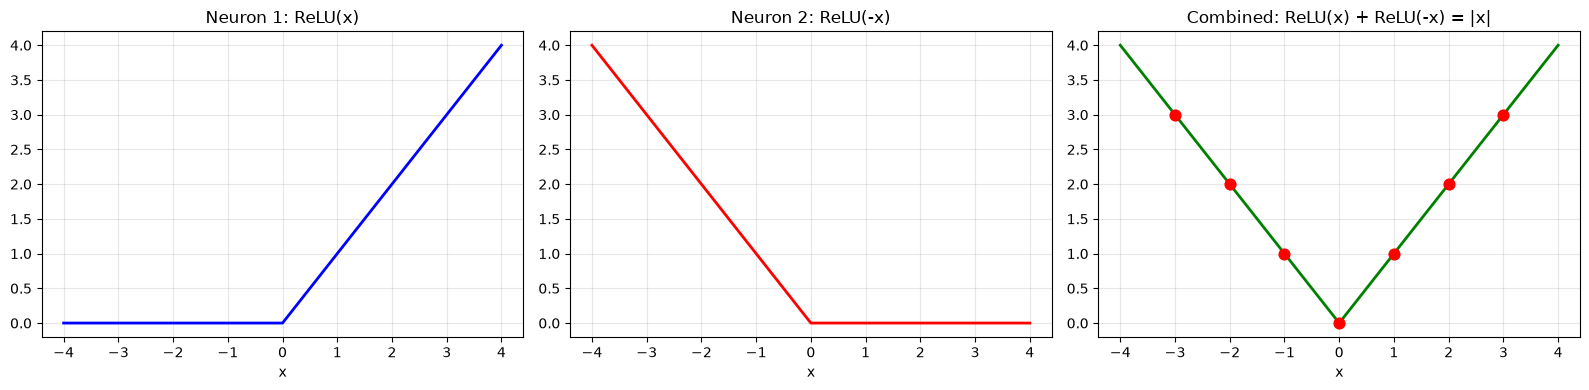

Two bent lines combine into a V-shape. Perfect fit!
This is what a hidden layer does: each neuron learns one bent piece.


In [5]:
# Show how two ReLU neurons create |x|
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x_vals = [x/10 for x in range(-40, 41)]

# Neuron 1: ReLU(x)
n1 = [relu(x) for x in x_vals]
axes[0].plot(x_vals, n1, 'b-', linewidth=2)
axes[0].set_title('Neuron 1: ReLU(x)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('x')

# Neuron 2: ReLU(-x)
n2 = [relu(-x) for x in x_vals]
axes[1].plot(x_vals, n2, 'r-', linewidth=2)
axes[1].set_title('Neuron 2: ReLU(-x)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel('x')

# Combined: |x| = ReLU(x) + ReLU(-x)
combined = [a + b for a, b in zip(n1, n2)]
axes[2].plot(x_vals, combined, 'g-', linewidth=2)
axes[2].scatter(X_train, Y_train, color='red', s=60, zorder=5)
axes[2].set_title('Combined: ReLU(x) + ReLU(-x) = |x|', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('x')

plt.tight_layout()
plt.show()

print("Two bent lines combine into a V-shape. Perfect fit!")
print("This is what a hidden layer does: each neuron learns one bent piece.")

---
## Part 3: Build a Hidden Layer Network

```
         w1          v1
x ---> [neuron 1] ---> ReLU --+
         w2          v2       +--> [output neuron] --> y_hat
x ---> [neuron 2] ---> ReLU --+
```

- **Hidden layer**: 2 neurons with ReLU
- **Output layer**: 1 neuron (no activation)

In [7]:
# Initialize the network
# Hidden layer weights (input -> hidden)
w1 = 1.0     # weight for hidden neuron 1
w2 = -1.0    # weight for hidden neuron 2

# Output layer weights (hidden -> output)
v1 = 1.0     # weight from hidden 1 to output
v2 = 1.0     # weight from hidden 2 to output

print("Network architecture:")
print(f"  Hidden neuron 1: z1 = {w1} * x, h1 = ReLU(z1)")
print(f"  Hidden neuron 2: z2 = {w2} * x, h2 = ReLU(z2)")
print(f"  Output: y_hat = {v1} * h1 + {v2} * h2")
print(f"\n  Total parameters: 4 (w1, w2, v1, v2)")

Network architecture:
  Hidden neuron 1: z1 = 1.0 * x, h1 = ReLU(z1)
  Hidden neuron 2: z2 = -1.0 * x, h2 = ReLU(z2)
  Output: y_hat = 1.0 * h1 + 1.0 * h2

  Total parameters: 4 (w1, w2, v1, v2)


In [8]:
# Forward pass: trace one input through the network
def forward(x, w1, w2, v1, v2):
    """Complete forward pass, saving all intermediate values."""
    # Hidden layer
    z1 = w1 * x           # pre-activation neuron 1
    h1 = relu(z1)         # post-activation neuron 1
    z2 = w2 * x           # pre-activation neuron 2
    h2 = relu(z2)         # post-activation neuron 2

    # Output
    y_hat = v1 * h1 + v2 * h2

    return y_hat, z1, h1, z2, h2

# Trace x=3 through the network
x = 3
y_hat, z1, h1, z2, h2 = forward(x, w1, w2, v1, v2)

print(f"Forward pass for x = {x}:")
print(f"  Hidden 1: z1 = {w1}*{x} = {z1},  h1 = ReLU({z1}) = {h1}")
print(f"  Hidden 2: z2 = {w2}*{x} = {z2},  h2 = ReLU({z2}) = {h2}")
print(f"  Output:   y_hat = {v1}*{h1} + {v2}*{h2} = {y_hat}")
print(f"  Actual:   |{x}| = {abs(x)}")
print(f"  Correct!")

Forward pass for x = 3:
  Hidden 1: z1 = 1.0*3 = 3.0,  h1 = ReLU(3.0) = 3.0
  Hidden 2: z2 = -1.0*3 = -3.0,  h2 = ReLU(-3.0) = 0
  Output:   y_hat = 1.0*3.0 + 1.0*0 = 3.0
  Actual:   |3| = 3
  Correct!


In [9]:
# Trace x=-3: the OTHER neuron activates
x = -3
y_hat, z1, h1, z2, h2 = forward(x, w1, w2, v1, v2)

print(f"Forward pass for x = {x}:")
print(f"  Hidden 1: z1 = {w1}*{x} = {z1},  h1 = ReLU({z1}) = {h1}  <-- BLOCKED")
print(f"  Hidden 2: z2 = {w2}*{x} = {z2},  h2 = ReLU({z2}) = {h2}  <-- active!")
print(f"  Output:   y_hat = {v1}*{h1} + {v2}*{h2} = {y_hat}")
print(f"  Actual:   |{x}| = {abs(x)}")
print(f"\n  The neurons take TURNS based on the input sign!")

Forward pass for x = -3:
  Hidden 1: z1 = 1.0*-3 = -3.0,  h1 = ReLU(-3.0) = 0  <-- BLOCKED
  Hidden 2: z2 = -1.0*-3 = 3.0,  h2 = ReLU(3.0) = 3.0  <-- active!
  Output:   y_hat = 1.0*0 + 1.0*3.0 = 3.0
  Actual:   |-3| = 3

  The neurons take TURNS based on the input sign!


In [11]:
# Test on all data points
print("Full network predictions vs actual:")
print("-" * 50)

for x, y in zip(X_train, Y_train):
    y_hat, z1, h1, z2, h2 = forward(x, w1, w2, v1, v2)
    status = "correct" if abs(y_hat - y) < 0.001 else "WRONG"
    active = "H1" if h1 > 0 else "H2" if h2 > 0 else "neither"
    print(f"  x={x:+d}: y_hat={y_hat:4.1f}, actual={y}, active={active}  [{status}]")

print("\nPerfect! With the right weights, 2 ReLU neurons solve y=|x|.")

Full network predictions vs actual:
--------------------------------------------------
  x=-3: y_hat= 3.0, actual=3, active=H2  [correct]
  x=-2: y_hat= 2.0, actual=2, active=H2  [correct]
  x=-1: y_hat= 1.0, actual=1, active=H2  [correct]
  x=+0: y_hat= 0.0, actual=0, active=neither  [correct]
  x=+1: y_hat= 1.0, actual=1, active=H1  [correct]
  x=+2: y_hat= 2.0, actual=2, active=H1  [correct]
  x=+3: y_hat= 3.0, actual=3, active=H1  [correct]

Perfect! With the right weights, 2 ReLU neurons solve y=|x|.


---
## Part 4: Backpropagation — How the Network Learns

The forward pass goes input -> output. **Backpropagation** goes output -> input, passing **blame** (gradients) backwards through the network.

```
Forward:   x --> z --> h --> y_hat --> loss
Backward:  x <-- z <-- h <-- y_hat <-- loss
           (gradients flow backwards)
```

### The chain rule

To find how weight `w1` affects the loss, we trace the path:

```
w1 affects z1
z1 affects h1 (through ReLU)
h1 affects y_hat
y_hat affects loss
```

Multiply all these effects together = the gradient for w1.

In [12]:
def backward(x, target, w1, w2, v1, v2):
    """One step of backpropagation. Returns gradients for all 4 weights."""

    # ---- FORWARD PASS (save everything) ----
    z1 = w1 * x
    h1 = relu(z1)
    z2 = w2 * x
    h2 = relu(z2)
    y_hat = v1 * h1 + v2 * h2

    loss = (y_hat - target) ** 2

    # ---- BACKWARD PASS ----

    # Step 1: How does loss change with y_hat?
    d_loss = 2 * (y_hat - target)

    # Step 2: Gradients for output weights (v1, v2)
    grad_v1 = d_loss * h1      # d(y_hat)/d(v1) = h1
    grad_v2 = d_loss * h2      # d(y_hat)/d(v2) = h2

    # Step 3: Blame passed to hidden neurons
    blame_h1 = d_loss * v1     # how much h1 contributed to the error
    blame_h2 = d_loss * v2

    # Step 4: Through ReLU gate
    # ReLU passes blame if z > 0, blocks if z <= 0
    blame_z1 = blame_h1 * (1 if z1 > 0 else 0)
    blame_z2 = blame_h2 * (1 if z2 > 0 else 0)

    # Step 5: Gradients for hidden weights (w1, w2)
    grad_w1 = blame_z1 * x     # d(z1)/d(w1) = x
    grad_w2 = blame_z2 * x

    return loss, grad_w1, grad_w2, grad_v1, grad_v2

In [13]:
# Walk through one backward pass
x, target = 2, 2   # |2| = 2

# Start with random-ish weights
w1_test, w2_test, v1_test, v2_test = 0.5, -0.3, 0.8, 0.6

loss, gw1, gw2, gv1, gv2 = backward(x, target, w1_test, w2_test, v1_test, v2_test)

y_hat_test = forward(x, w1_test, w2_test, v1_test, v2_test)[0]

print(f"Forward:  x={x}, target={target}, y_hat={y_hat_test:.4f}, loss={loss:.4f}")
print(f"\nBackward (gradients):")
print(f"  grad_w1 = {gw1:+.4f}  (hidden weight 1)")
print(f"  grad_w2 = {gw2:+.4f}  (hidden weight 2)")
print(f"  grad_v1 = {gv1:+.4f}  (output weight 1)")
print(f"  grad_v2 = {gv2:+.4f}  (output weight 2)")
print(f"\nNegative gradient = increase this weight to reduce loss.")
print(f"Positive gradient = decrease this weight to reduce loss.")

Forward:  x=2, target=2, y_hat=0.8000, loss=1.4400

Backward (gradients):
  grad_w1 = -3.8400  (hidden weight 1)
  grad_w2 = -0.0000  (hidden weight 2)
  grad_v1 = -2.4000  (output weight 1)
  grad_v2 = -0.0000  (output weight 2)

Negative gradient = increase this weight to reduce loss.
Positive gradient = decrease this weight to reduce loss.


### The ReLU gate — why it matters

In [14]:
# Show the ReLU gate effect on gradients
print("The ReLU Gate:")
print("=" * 50)
print("  When z > 0: gate OPEN  --> gradient passes through")
print("  When z <= 0: gate SHUT --> gradient = 0 (blocked!)")
print()

for x in [-3, -1, 0, 1, 3]:
    z1 = w1_test * x
    z2 = w2_test * x
    gate1 = "OPEN" if z1 > 0 else "SHUT"
    gate2 = "OPEN" if z2 > 0 else "SHUT"
    print(f"  x={x:+d}: z1={z1:+.1f} [{gate1}]  z2={z2:+.1f} [{gate2}]")

print("\nA shut gate means that weight CAN'T learn from this input.")
print("This is the 'dead ReLU' problem -- a risk in deep networks.")

The ReLU Gate:
  When z > 0: gate OPEN  --> gradient passes through
  When z <= 0: gate SHUT --> gradient = 0 (blocked!)

  x=-3: z1=-1.5 [SHUT]  z2=+0.9 [OPEN]
  x=-1: z1=-0.5 [SHUT]  z2=+0.3 [OPEN]
  x=+0: z1=+0.0 [SHUT]  z2=-0.0 [SHUT]
  x=+1: z1=+0.5 [OPEN]  z2=-0.3 [SHUT]
  x=+3: z1=+1.5 [OPEN]  z2=-0.9 [SHUT]

A shut gate means that weight CAN'T learn from this input.
This is the 'dead ReLU' problem -- a risk in deep networks.


---
## Part 5: Train the Network

Now let's start with **random weights** and let backpropagation discover the right ones.

> **Predict first:** will it always find |x|? Random starts matter — with `random.seed(42)` one hidden ReLU can die (its z stays negative, so it never receives a gradient) and training sticks at loss 2.0. If that happens, switch to `random.seed(1)` and compare. This is the dead-ReLU problem in action.

In [15]:
import random
random.seed(42)

# Random starting weights
w1 = random.uniform(-1, 1)
w2 = random.uniform(-1, 1)
v1 = random.uniform(-1, 1)
v2 = random.uniform(-1, 1)

lr = 0.01
epochs = 500

loss_history = []
w1_hist, w2_hist, v1_hist, v2_hist = [], [], [], []

print(f"Starting weights: w1={w1:.4f}, w2={w2:.4f}, v1={v1:.4f}, v2={v2:.4f}")
print(f"Training for {epochs} epochs...\n")

for epoch in range(1, epochs + 1):
    epoch_loss = 0

    for x, target in zip(X_train, Y_train):
        # Backpropagation!
        loss, gw1, gw2, gv1, gv2 = backward(x, target, w1, w2, v1, v2)

        # Update all weights
        w1 -= lr * gw1
        w2 -= lr * gw2
        v1 -= lr * gv1
        v2 -= lr * gv2

        epoch_loss += loss

    avg_loss = epoch_loss / len(X_train)
    loss_history.append(avg_loss)
    w1_hist.append(w1)
    w2_hist.append(w2)
    v1_hist.append(v1)
    v2_hist.append(v2)

    if epoch in [1, 10, 50, 100, 200, 500]:
        print(f"  Epoch {epoch:3d}: loss={avg_loss:.6f}  "
              f"w1={w1:.3f} w2={w2:.3f} v1={v1:.3f} v2={v2:.3f}")

print(f"\nFinal loss: {loss_history[-1]:.8f}")

Starting weights: w1=0.2789, w2=-0.9500, v1=-0.4499, v2=-0.5536
Training for 500 epochs...

  Epoch   1: loss=6.498204  w1=0.146 w2=-0.764 v1=-0.374 v2=-0.196
  Epoch  10: loss=2.008459  w1=-0.004 w2=-1.107 v1=-0.317 v2=0.869
  Epoch  50: loss=2.000000  w1=-0.005 w2=-1.124 v1=-0.317 v2=0.891
  Epoch 100: loss=2.000000  w1=-0.005 w2=-1.124 v1=-0.317 v2=0.891
  Epoch 200: loss=2.000000  w1=-0.005 w2=-1.124 v1=-0.317 v2=0.891
  Epoch 500: loss=2.000000  w1=-0.005 w2=-1.124 v1=-0.317 v2=0.891

Final loss: 2.00000000


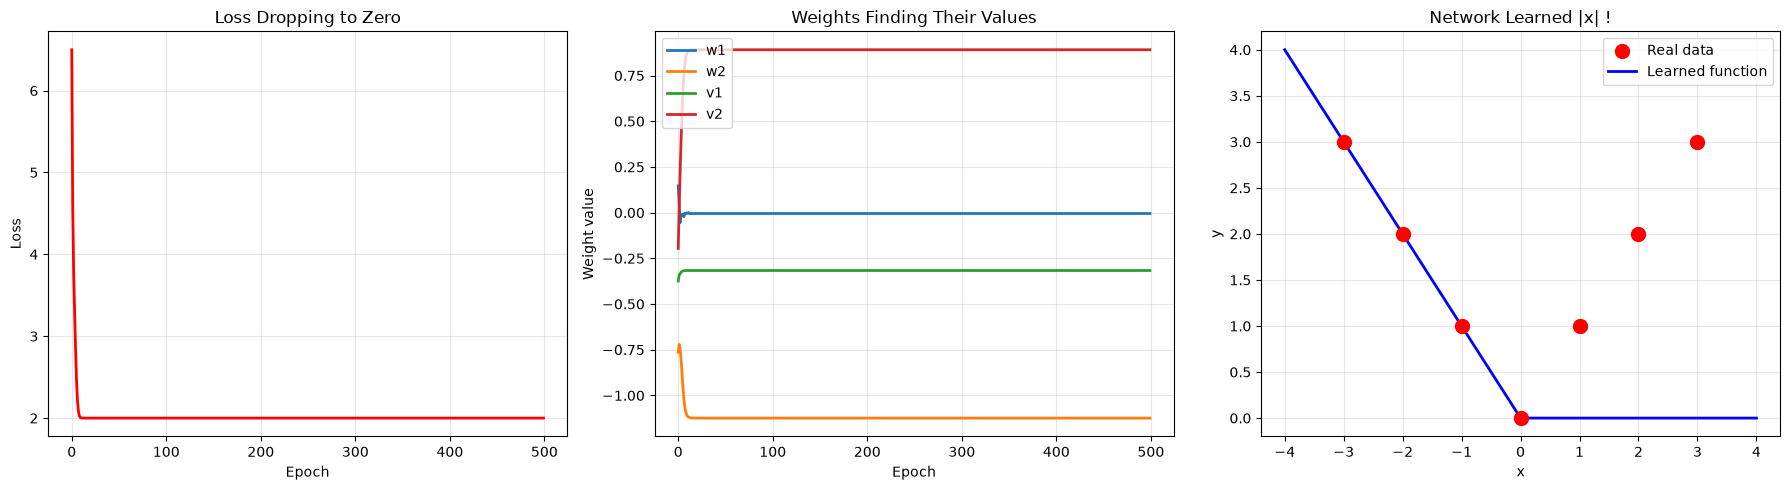

In [16]:
# Visualize training
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(loss_history, 'r-', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Weights over time
axes[1].plot(w1_hist, label='w1', linewidth=2)
axes[1].plot(w2_hist, label='w2', linewidth=2)
axes[1].plot(v1_hist, label='v1', linewidth=2)
axes[1].plot(v2_hist, label='v2', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Weight value')
axes[1].set_title('Weights Finding Their Values')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learned function vs data
x_test = [x/10 for x in range(-40, 41)]
y_pred = [forward(x, w1, w2, v1, v2)[0] for x in x_test]
axes[2].scatter(X_train, Y_train, color='red', s=100, zorder=5, label='Real data')
axes[2].plot(x_test, y_pred, 'b-', linewidth=2, label='Learned function')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Network Learned |x| !')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Test predictions
print("Predictions after training:")
print("-" * 40)
for x in [-4, -2, 0, 2, 4]:
    y_hat = forward(x, w1, w2, v1, v2)[0]
    print(f"  x={x:+d}: predicted={y_hat:.4f}, actual={abs(x)}")

final_loss = loss_history[-1]
if final_loss < 0.01:
    print(f"\nThe network learned |x| from scratch using backpropagation! (final loss {final_loss:.4f})")
    print("It even works on x=4 and x=-4, which it never trained on.")
else:
    print(f"\nStuck at loss {final_loss:.2f}: a hidden ReLU died (its z stayed negative, so no gradient reached it).")
    print("This is the dead-ReLU problem from Part D. Change random.seed(42) to random.seed(1) above and re-run.")

---
## Part 6: Experiments

### Experiment 1: More hidden neurons

In [18]:
# What if we use 4 hidden neurons instead of 2?
def forward_4h(x, weights):
    """4-hidden-neuron network."""
    w1, w2, w3, w4, v1, v2, v3, v4 = weights
    h1 = relu(w1 * x)
    h2 = relu(w2 * x)
    h3 = relu(w3 * x)
    h4 = relu(w4 * x)
    return v1*h1 + v2*h2 + v3*h3 + v4*h4

def train_4h(X, Y, lr=0.01, epochs=500):
    weights = [random.uniform(-1, 1) for _ in range(8)]
    nudge = 0.0001
    losses = []

    for epoch in range(epochs):
        # Calculate loss
        preds = [forward_4h(x, weights) for x in X]
        loss = mse_loss(preds, Y)
        losses.append(loss)

        # Numerical gradient for each weight
        for i in range(len(weights)):
            w_nudged = weights.copy()
            w_nudged[i] += nudge
            preds_nudged = [forward_4h(x, w_nudged) for x in X]
            loss_nudged = mse_loss(preds_nudged, Y)
            grad = (loss_nudged - loss) / nudge
            weights[i] -= lr * grad

    return weights, losses

random.seed(42)
w4h, l4h = train_4h(X_train, Y_train)

x_test = [x/10 for x in range(-40, 41)]
y_2h = [forward(x, w1, w2, v1, v2)[0] for x in x_test]
y_4h = [forward_4h(x, w4h) for x in x_test]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(X_train, Y_train, color='red', s=100, zorder=5, label='Data')
ax.plot(x_test, y_2h, 'b-', linewidth=2, label='2 hidden neurons')
ax.plot(x_test, y_4h, 'g--', linewidth=2, label='4 hidden neurons')
ax.set_title('2 vs 4 Hidden Neurons', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"2 hidden neurons final loss: {loss_history[-1]:.6f}")
print(f"4 hidden neurons final loss: {l4h[-1]:.6f}")
print("More neurons = more flexibility, but also more parameters to train.")

OverflowError: (34, 'Result too large')

### Experiment 2: Learn a harder function (y = x^2)

In [19]:
# Can our network learn a parabola?
X_sq = [-3, -2, -1, 0, 1, 2, 3]
Y_sq = [ 9,  4,  1, 0, 1, 4, 9]   # y = x^2

random.seed(42)
w_sq, l_sq = train_4h(X_sq, Y_sq, lr=0.001, epochs=2000)

y_sq_pred = [forward_4h(x, w_sq) for x in x_test]
y_sq_true = [x**2 for x in x_test]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_sq, Y_sq, color='red', s=100, zorder=5, label='Data')
axes[0].plot(x_test, y_sq_pred, 'b-', linewidth=2, label='4-neuron network')
axes[0].plot(x_test, y_sq_true, 'g--', linewidth=1, alpha=0.5, label='True x^2')
axes[0].set_title('Learning y = x^2 with 4 ReLU neurons', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(l_sq, 'r-', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training loss for x^2', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("ReLU neurons approximate curves with straight-line segments.")
print("More neurons = more segments = smoother approximation.")

OverflowError: (34, 'Result too large')

---
## Part 7: Summary

| Concept | What you learned |
|---|---|
| **Linear limit** | One neuron = straight line. Can't fit curves. |
| **ReLU** | `max(0, z)` — adds the bend that makes curves possible |
| **Hidden layer** | Neurons that discover their own features |
| **Forward pass** | x -> z -> ReLU -> h -> output |
| **Backward pass** | Blame flows from loss back to every weight |
| **ReLU gate** | Passes gradients when z > 0, blocks when z <= 0 |
| **Training** | Forward + backward + update, repeated for every data point |

**The key insight:** Backpropagation lets us train networks with ANY number of layers. Each layer learns its own features. This is what makes deep learning "deep".

**Next lab:** We add Sigmoid and BCE loss to build a **classifier** — the exact architecture used by GAN Discriminators.